# [실습 6-1] 과적합 시각화 — 문제집 만점, 본시험 낙제

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 30~40분 (CPU 충분) |
| 본문 연계 | 6.3 일반화 — 기계학습의 진짜 목표 |
| 선수 실습 | 없음 |
| 준비 | 부록 B.1·B.3 참고 |

다항 회귀의 차수를 바꿔 가며 **과소적합 → 적정 → 과적합**
스펙트럼을 직접 그리고, 학습 곡선과 교차검증으로
"일반화 성능"을 측정하는 절차를 익힌다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch06/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from utils import plot_style, viz

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("NumPy", np.__version__,
      "/ scikit-learn", sklearn.__version__)

Python 3.12.6
NumPy 2.4.6 / scikit-learn 1.9.0


### [셀 1] 합성 데이터 생성과 훈련/테스트 분할 📖

In [2]:
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)
x = rng.uniform(-3, 3, 40)
y = x**3 - 3*x + rng.normal(0, 2, 40)  # 참 함수 + 잡음

x_tr, x_te, y_tr, y_te = train_test_split(
    x, y, test_size=0.25, random_state=42)
print(f"훈련 {len(x_tr)}건 / 테스트 {len(x_te)}건")
# 철칙: 테스트셋은 마지막에 단 한 번만 쓴다(6.2 훈련/검증/테스트 분할)

훈련 30건 / 테스트 10건


**핵심 포인트**
- 참 함수(3차 곡선)를 우리는 알지만 **모델은 모른다** — 잡음 낀 40개 점만 보고 곡선을 추측해야 한다(기계학습의 상황 그 자체).
- `random_state` 고정으로 책과 같은 데이터가 재현된다.

기대 출력: `훈련 30건 / 테스트 10건`

### [셀 2] 다항 회귀 적합 함수 📖

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (PolynomialFeatures,
                                   StandardScaler)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def fit_poly(degree):
    """차수를 받아 학습 → (예측 함수, 훈련·테스트 오차)."""
    model = make_pipeline(
        PolynomialFeatures(degree),
        StandardScaler(),
        LinearRegression())
    model.fit(x_tr[:, None], y_tr)
    e_tr = mean_squared_error(
        y_tr, model.predict(x_tr[:, None]))
    e_te = mean_squared_error(
        y_te, model.predict(x_te[:, None]))
    return (lambda xs: model.predict(xs[:, None]),
            e_tr, e_te)

_, e_tr, e_te = fit_poly(3)
print(f"3차: 훈련 오차 {e_tr:.2f} / 테스트 {e_te:.2f}")

3차: 훈련 오차 1.66 / 테스트 3.32


**핵심 포인트**
- 차수가 **모델 복잡도**의 손잡이다: 1차 = 직선(단순), 15차 = 요동치는 곡선(복잡).
- 같은 모델을 훈련·테스트 양쪽에서 채점하는 것이 이 장의 핵심 습관이다 — 둘의 **간격**이 과적합의 신호.

### [셀 3] 과소적합 → 적정 → 과적합 3연 곡선 📖

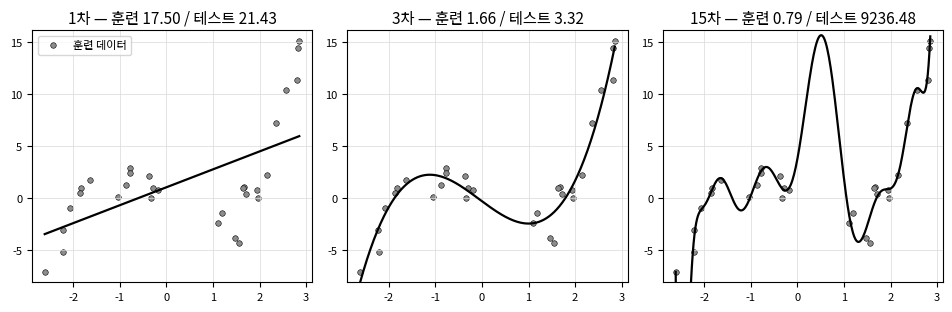

 1차: 훈련  17.50 / 테스트    21.43
 3차: 훈련   1.66 / 테스트     3.32
15차: 훈련   0.79 / 테스트  9236.48


In [4]:
fits = {d: fit_poly(d) for d in (1, 3, 15)}
viz.plot_poly_panels(x_tr, y_tr, x_te, y_te, fits)
plt.show()

for d, (_, e_tr, e_te) in fits.items():
    print(f"{d:>2}차: 훈련 {e_tr:6.2f} / "
          f"테스트 {e_te:8.2f}")

**핵심 포인트**
- **1차(과소적합)**: 데이터의 굽이를 직선이 못 따라간다 — 훈련·테스트 오차 모두 크다.
- **3차(적정)**: 매끈하게 추세를 탄다 — 두 오차가 모두 작고 서로 가깝다.
- **15차(과적합)**: 훈련 점을 한 점 한 점 관통하며 요동 — 훈련 오차는 거의 0인데 테스트 오차가 폭발한다. "문제집 만점, 본시험 낙제"(6.3 모델 복잡도와 적합)다.
- 본문 [그림 6-x]와 같은 구도다 — 그림 함수는 `utils/viz.py`(코드 정책 ③).

실패 시 대처: 15차 적합에서 수치 경고가 떠도 정상이다(불안정 그 자체가 과적합의 증상). 그림이 지면과 다르면 [셀 1]의 `random_state` 복원을 확인한다.

### [셀 4] 학습 곡선 — 데이터가 늘면 간격이 줄어든다 📖

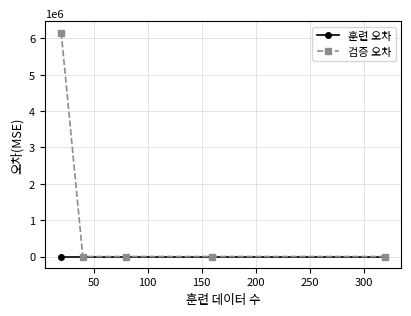

In [5]:
def learning_curve_15(sizes, seed=7):
    """15차 모델의 훈련·검증 오차를 데이터 양별로 측정."""
    rng2 = np.random.default_rng(seed)
    xs = rng2.uniform(-3, 3, max(sizes) + 100)
    ys = xs**3 - 3*xs + rng2.normal(0, 2, len(xs))
    x_va, y_va = xs[-100:], ys[-100:]   # 고정 검증셋
    e_tr_list, e_va_list = [], []
    for n in sizes:
        model = make_pipeline(
            PolynomialFeatures(15), StandardScaler(),
            LinearRegression())
        model.fit(xs[:n, None], ys[:n])
        e_tr_list.append(mean_squared_error(
            ys[:n], model.predict(xs[:n, None])))
        e_va_list.append(mean_squared_error(
            y_va, model.predict(x_va[:, None])))
    return e_tr_list, e_va_list

sizes = [20, 40, 80, 160, 320]
e_tr_l, e_va_l = learning_curve_15(sizes)
viz.plot_learning_curve(sizes, e_tr_l, e_va_l)
plt.show()

**핵심 포인트**
- 데이터가 적을 때: 훈련 오차 ≈ 0, 검증 오차는 크다 — **넓은 간격 = 과적합 증상**(6.3 〈과적합의 진단〉의 학습 곡선 판독법).
- 데이터가 늘수록 간격이 좁아진다 — 과적합의 1차 처방이 "데이터 추가"인 이유를 눈으로 확인.
- 같은 구도의 도해가 본문 6.3 〈과적합의 진단〉에 있다 — 증상 → 원인 → 처방의 순서로 읽는다.

### [셀 5] k-겹 교차검증으로 차수 선택 📖

In [6]:
from sklearn.model_selection import cross_val_score

degrees = range(1, 13)
cv_err = []
for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(d), StandardScaler(),
        LinearRegression())
    scores = cross_val_score(
        model, x_tr[:, None], y_tr, cv=5,
        scoring="neg_mean_squared_error")
    cv_err.append(-scores.mean())

best = list(degrees)[int(np.argmin(cv_err))]
print(f"교차검증(k=5)이 고른 차수: {best}차")

# 이제 단 한 번, 테스트셋으로 최종 확인한다
_, _, e_te = fit_poly(best)
print(f"최종 테스트 오차: {e_te:.2f}")

교차검증(k=5)이 고른 차수: 3차
최종 테스트 오차: 3.32


**핵심 포인트**
- 차수 선택(모델 선택)에 테스트셋을 쓰면 안 된다 — 훈련 데이터 안에서 5겹 교차검증으로 고르고, 테스트셋은 **최종 확인 단 한 번**(6.2 훈련/검증/테스트 분할 철칙의 실전 적용).
- 교차검증이 고른 차수가 참 함수(3차)와 일치하는지 확인하자.

기대 출력: `교차검증(k=5)이 고른 차수: 3차`

실패 시 대처: 2차나 4차가 나와도 오답이 아니다 — 잡음 수준에 따라 이웃 차수가 뽑힐 수 있음을 해석해 보자(단, 기본 시드에서는 3차).

### [보조 2] 모델 복잡도 U자 곡선 — 차수 전 구간 요약

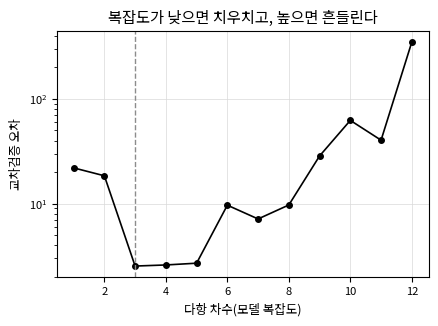

In [7]:
fig, ax = plt.subplots(figsize=(4.8, 3.2))
ax.plot(list(degrees), cv_err, "-o", color="black",
        ms=4, lw=1.2)
ax.axvline(best, color="#8c8c8c", ls="--", lw=1.0)
ax.set_xlabel("다항 차수(모델 복잡도)")
ax.set_ylabel("교차검증 오차")
ax.set_yscale("log")
ax.set_title("복잡도가 낮으면 치우치고, 높으면 흔들린다")
plt.show()

왼쪽(저차수)은 과소적합으로 오차가 높고, 오른쪽(고차수)은 과적합으로 다시 치솟는다 — 6.3 편향-분산 트레이드오프의 U자 곡선이다.

### [보조 3] 평가지표 미니 과제 — 혼동 행렬에서 4지표 계산 (6.4 연계)

In [8]:
def metrics(tp, fp, fn, tn):
    """혼동 행렬 4칸 → 분류 평가지표 4종(6.4)."""
    acc = (tp + tn) / (tp + fp + fn + tn)
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = (2 * prec * rec / (prec + rec)
          if prec + rec else 0.0)
    return acc, prec, rec, f1

# "정확도의 함정" 예제: 1,000명 중 암 환자 10명,
# 모두 '정상'이라고만 답하는 엉터리 모델
acc, prec, rec, f1 = metrics(tp=0, fp=0, fn=10, tn=990)
print(f"정확도 {acc:.1%} — 그러나 재현율 {rec:.1%}!")

정확도 99.0% — 그러나 재현율 0.0%!


정확도 99%짜리 무용지물 — 6.4 분류 평가지표의 Before/After 사례를 숫자로 재현했다. 이 `metrics()` 함수는 **14장 공정성 실습에서 집단별로 재사용**된다(6장이 허브 장인 이유).

### [심화 1] 릿지 정규화 전후 비교 (연습문제 심화·9장 예고)

In [9]:
from sklearn.linear_model import Ridge

def fit_poly_ridge(degree, alpha):
    """릿지(가중치 벌점) 적용 다항 회귀."""
    model = make_pipeline(
        PolynomialFeatures(degree), StandardScaler(),
        Ridge(alpha=alpha))
    model.fit(x_tr[:, None], y_tr)
    e_te = mean_squared_error(
        y_te, model.predict(x_te[:, None]))
    return (lambda xs: model.predict(xs[:, None]),
            None, e_te)

# TODO: alpha를 0.01/1/100으로 바꿔 15차의 요동이
#       어떻게 잦아드는지 관찰하고 결과를 해석해 보자.
_, _, e0 = fit_poly(15)
_, _, e1 = fit_poly_ridge(15, alpha=1.0)
print(f"15차 테스트 오차: 정규화 없음 {e0:.1f} → "
      f"릿지 {e1:.1f}")

15차 테스트 오차: 정규화 없음 9236.5 → 릿지 4.4


---
## 마무리

- 과소적합·과적합은 훈련/테스트 **두 오차의 간격**으로 진단한다 — 그림(3연 곡선)과 곡선(학습 곡선) 모두 같은 이야기다.
- 모델 선택은 교차검증으로, 테스트셋은 마지막에 단 한 번 — 이 절차가 6.5 워크플로의 뼈대다.
- 과적합 처방 3종: 데이터 추가([셀 4]), 모델 단순화([셀 5]), 정규화([심화 1] → 9장에서 본격 등장).

**연습문제 연계**: [응용] 학습 곡선 그래프 해석 문항은 [셀 4] 출력으로, [심화] 정규화 실험은 [심화 1] 뼈대로 수행한다.

**다음 실습**: [실습 7-1] 붓꽃 분류 — 분류기 4종 비교 (`ch07/lab-07-01_iris-classifiers.ipynb`)